# Introduction to Machine Learning
## Homework 1
### Student Name: Amirali Dehghani
### Student ID: 810102443


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math, matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
from pathlib import Path


#### Question 4
**Part d**

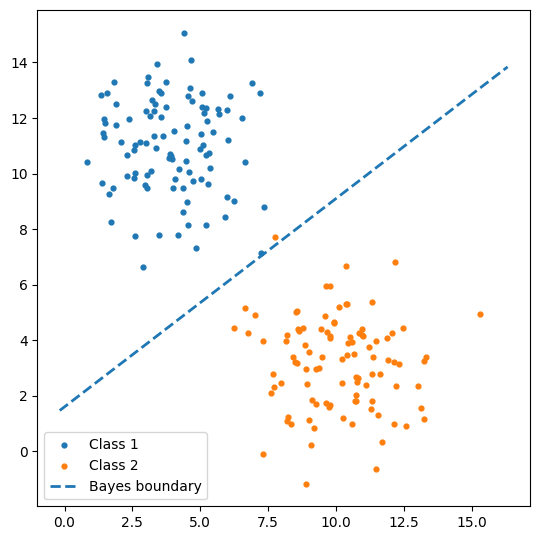

In [3]:
mu1 = np.array([4, 11])
mu2 = np.array([10, 3])
var = 3 * np.eye(2)
p1 = 0.6
p2 = 0.4
n = 100
X1 = np.random.multivariate_normal(mu1, var, n)
X2 = np.random.multivariate_normal(mu2, var, n)
plt.figure(figsize=(5.5, 5.5))
plt.scatter(X1[:, 0], X1[:, 1], s=12, label='Class 1')
plt.scatter(X2[:, 0], X2[:, 1], s=12, label='Class 2')

xmin = min(X1[:, 0].min(), X2[:, 0].min()) - 1
xmax = max(X1[:, 0].max(), X2[:, 0].max()) + 1
x = np.linspace(xmin, xmax, 200)

y = 0.75 * x + 1.598
plt.plot(x, y, '--', lw=2, label='Bayes boundary')

plt.legend()
plt.tight_layout()
plt.show()


#### Question 7
**Part 2**

In [6]:
X = np.array([
    [0, 1],
    [1, 1],
    [0, 0],
    [1, 1],
    [1, 1],
    [0, 0],
    [1, 0],
    [1, 0],
    [1, 1],
    [1, 0]
])
y = np.array([1,
              1,
              0,
              1,
              1,
              0,
              0,
              0,
              1,
              0])
# A
p_y1 = np.mean(y == 1)
p_y0 = np.mean(y == 0)
print("-" * 20 + "A" + "-" * 20)
print(f"P(y=1) = {p_y1}")
print(f"P(y=0) = {p_y0}")
# B
p_x1_y1 = np.mean(X[y == 1, 0] == 1)
p_x2_y1 = np.mean(X[y == 1, 1] == 1)
p_x1_y0 = np.mean(X[y == 0, 0] == 1)
p_x2_y0 = np.mean(X[y == 0, 1] == 1)
print("-" * 20 + "B" + "-" * 20)
print(f"P(x1=1 | y=1) = {p_x1_y1}")
print(f"P(x2=1 | y=1) = {p_x2_y1}")
print(f"P(x1=1 | y=0) = {p_x1_y0}")
print(f"P(x2=1 | y=0) = {p_x2_y0}")
# C
x = np.array([1, 1])
s1 = p_y1 * (p_x1_y1 ** x[0]) * (p_x2_y1 ** x[1])
s0 = p_y0 * (p_x1_y0 ** x[0]) * (p_x2_y0 ** x[1])
s = s1 + s0
p_y1_x = s1 / s
p_y0_x = s0 / s

predicted_label = 1 if p_y1_x > p_y0_x else 0
print("-" * 20 + "C" + "-" * 20)
print(p_y1_x, p_y0_x)
print(predicted_label)

--------------------A--------------------
P(y=1) = 0.5
P(y=0) = 0.5
--------------------B--------------------
P(x1=1 | y=1) = 0.8
P(x2=1 | y=1) = 1.0
P(x1=1 | y=0) = 0.6
P(x2=1 | y=0) = 0.0
--------------------C--------------------
1.0 0.0
1


#### Question 8

In [11]:
TRAIN_PATH = "data/train"
TEST_PATH = "data/test"

def load_data(path):
    X, y1, y2 = [], [], []
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            y1.append(1 if parts[1].lower() == "spam" else 0)
            y2.append(1 if parts[1].lower() == "ham" else 0)
            wc = {}
            toks = parts[2:]
            for w, c in zip(toks[::2], toks[1::2]):
                if c.isdigit():
                    wc[w] = wc.get(w, 0) + int(c)
            X.append(wc)
    return X, y1, y2

x_train, y1_train, y2_train = load_data(TRAIN_PATH)
x_test, y1_test, y2_test = load_data(TEST_PATH)


**Part 2**

In [13]:
count_mails = len(x_train)
spam_count = sum(y1_train)
ham_count = sum(y2_train)
p_spam = spam_count / count_mails
p_ham = ham_count / count_mails
print(f"Mails in training set: {count_mails}")
print(f"Spam mails: {spam_count}")
print(f"Ham mails: {ham_count}")
print(f"P(spam) = {p_spam}")
print(f"P(ham) = {p_ham}")



Mails in training set: 9000
Spam mails: 5163
Ham mails: 3837
P(spam) = 0.5736666666666667
P(ham) = 0.42633333333333334


**Part 3**

In [23]:
V = set()
for d in x_train:
    V.update(d.keys())
V = sorted(V)
V_size = len(V)

spam_counts = Counter()
ham_counts = Counter()
spam_total = 0
ham_total = 0
for d, y in zip(x_train, y1_train):
    if y == 1:
        for w, c in d.items():
            spam_counts[w] += c
            spam_total += c
    else:
        for w, c in d.items():
            ham_counts[w] += c
            ham_total += c

def cond_probs(m):
    p = 1.0 / V_size
    denom_spam = spam_total + m
    denom_ham = ham_total + m
    Pw_spam = {}
    Pw_ham = {}
    for w in V:
        ni_s = spam_counts.get(w, 0)
        ni_h = ham_counts.get(w, 0)
        Pw_spam[w] = (ni_s + m * p) / denom_spam
        Pw_ham[w] = (ni_h + m * p) / denom_ham
    return Pw_spam, Pw_ham

m_base = V_size
Pw_spam, Pw_ham = cond_probs(m_base)
top_spam = sorted(V, key=lambda w: Pw_spam[w], reverse=True)[:5]
top_ham = sorted(V, key=lambda w: Pw_ham[w], reverse=True)[:5]
print("Top spam words:\n")
for word in top_spam:
    print(f"Spam word: {word}, P(word|spam) = {Pw_spam[word]}")
print(20 * '-')
print("Top ham words:\n")
for word in top_ham:
    print(f"Ham word: {word}, P(word|ham) = {Pw_ham[word]}")

Top spam words:

Spam word: enron, P(word|spam) = 0.0381943878447375
Spam word: a, P(word|spam) = 0.023618529446035274
Spam word: corp, P(word|spam) = 0.02173790984979796
Spam word: the, P(word|spam) = 0.02142517760233378
Spam word: to, P(word|spam) = 0.019687038335056983
--------------------
Top ham words:

Ham word: aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa, P(word|ham) = 0.044321708617828505
Ham word: enron, P(word|ham) = 0.04244372379371936
Ham word: the, P(word|ham) = 0.0331690756387682
Ham word: to, P(word|ham) = 0.025329676593911908
Ham word: a, P(word|ham) = 0.017736664090903333


**Part 4**

In [29]:
def predict_docs(X, Pw_spam, Pw_ham, logP_spam, logP_ham):
    preds = []
    for d in X:
        s_spam = logP_spam
        s_ham = logP_ham
        for w, c in d.items():
            ps = Pw_spam.get(w)
            ph = Pw_ham.get(w)
            if ps is not None and ph is not None:
                s_spam += c * math.log(ps)
                s_ham += c * math.log(ph)
        preds.append(1 if s_spam >= s_ham else 0)
    return preds

def accuracy(y_true, y_pred):
    return sum(int(a == b) for a, b in zip(y_true, y_pred)) / len(y_true)

logP_spam = math.log(p_spam)
logP_ham = math.log(p_ham)
y_pred_test = predict_docs(x_test, Pw_spam, Pw_ham, logP_spam, logP_ham)
acc = accuracy(y1_test, y_pred_test)
print("Accuracy on test:", acc)

Accuracy on test: 0.902


**Part 5**

best_m: 50000
best_accuracy: 0.906


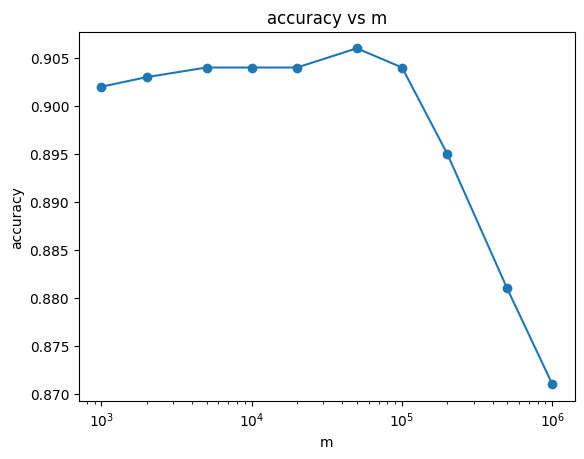

In [30]:
m_list = [V_size * k for k in [1,2,5,10,20,50,100,200,500,1000]]
accs = []
for m in m_list:
    Pw_s, Pw_h = cond_probs(m)
    y_pred = predict_docs(x_test, Pw_s, Pw_h, math.log(p_spam), math.log(p_ham))
    accs.append(accuracy(y1_test, y_pred))

best_idx = max(range(len(m_list)), key=lambda i: accs[i])
best_m, best_acc = m_list[best_idx], accs[best_idx]
print("best_m:", best_m)
print("best_accuracy:", best_acc)

plt.figure()
plt.plot(m_list, accs, marker="o")
plt.xscale("log")
plt.xlabel("m")
plt.ylabel("accuracy")
plt.title("accuracy vs m")
plt.show()

#### Question 9

**Part 1**

In [68]:
img_dir = Path("Images")
files = sorted(img_dir.glob("*.jpg"))
names = np.array([p.name for p in files])

def score_warmth(p):
    a = np.asarray(Image.open(p).convert("RGB"), dtype=np.float32)/255.0
    return float(a[...,0].mean() - a[...,2].mean())

scores = np.array([score_warmth(p) for p in files])
thr_med = float(np.median(scores))
pred_med = np.where(scores >= thr_med, "warm", "cold")

**Part 2**

In [73]:
y_true = np.array(["warm" if n.lower().startswith("s") else "cold" for n in names])

def cm_pr_re(y_true, y_pred, pos="warm"):
    tp = int(np.sum((y_true==pos)&(y_pred==pos)))
    fp = int(np.sum((y_true!=pos)&(y_pred==pos)))
    tn = int(np.sum((y_true!=pos)&(y_pred!=pos)))
    fn = int(np.sum((y_true==pos)&(y_pred!=pos)))
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    return tp, fp, tn, fn, prec, rec

tp_m, fp_m, tn_m, fn_m, pr_m, re_m = cm_pr_re(y_true, pred_med, pos="warm")
acc_m = float((pred_med==y_true).mean())

print("=== Warmth model (threshold = median) ===")
print("Confusion matrix (positive = warm):")
print(f"TP: {tp_m}  FP: {fp_m}  TN: {tn_m}  FN: {fn_m}")
print("Metrics:")
print(f"Precision (warm): {pr_m:.3f}")
print(f"Recall    (warm): {re_m:.3f}")
print(f"Accuracy:         {acc_m:.3f}")




=== Warmth model (threshold = median) ===
Confusion matrix (positive = warm):
TP: 34  FP: 6  TN: 34  FN: 6
Metrics:
Precision (warm): 0.850
Recall    (warm): 0.850
Accuracy:         0.850


**Part 3**

In [74]:
vals = np.unique(scores)
best_acc = -1.0
best_thr = thr_med
for t in vals:
    p = np.where(scores >= t, "warm", "cold")
    acc = (p == y_true).mean()
    if acc > best_acc:
        best_acc = acc
        best_thr = float(t)

pred_opt = np.where(scores >= best_thr, "warm", "cold")
tp_o, fp_o, tn_o, fn_o, pr_o, re_o = cm_pr_re(y_true, pred_opt, pos="warm")
acc_o = float((pred_opt == y_true).mean())

print("=== Warmth model (threshold = optimal) ===")
print(f"Best threshold: {best_thr:.6f}")
print(f"Accuracy: {acc_o:.3f}")
print("Confusion matrix (positive = warm):")
print(f"TP: {tp_o}  FP: {fp_o}  TN: {tn_o}  FN: {fn_o}")
print("Metrics:")
print(f"Precision (warm): {pr_o:.3f}")
print(f"Recall    (warm): {re_o:.3f}")


=== Warmth model (threshold = optimal) ===
Best threshold: 0.110282
Accuracy: 0.850
Confusion matrix (positive = warm):
TP: 36  FP: 8  TN: 32  FN: 4
Metrics:
Precision (warm): 0.818
Recall    (warm): 0.900


**Part 4**

name	score	true	pred
c21.jpg	0.1233	cold	warm
c28.jpg	0.1439	cold	warm
c29.jpg	0.3923	cold	warm
c34.jpg	0.3990	cold	warm
c35.jpg	0.4570	cold	warm
c37.jpg	0.1647	cold	warm
c38.jpg	0.4046	cold	warm
c39.jpg	0.4885	cold	warm
s21.jpg	-0.1866	warm	cold
s36.jpg	0.0022	warm	cold
s7.jpg	0.0320	warm	cold
s8.jpg	0.0180	warm	cold


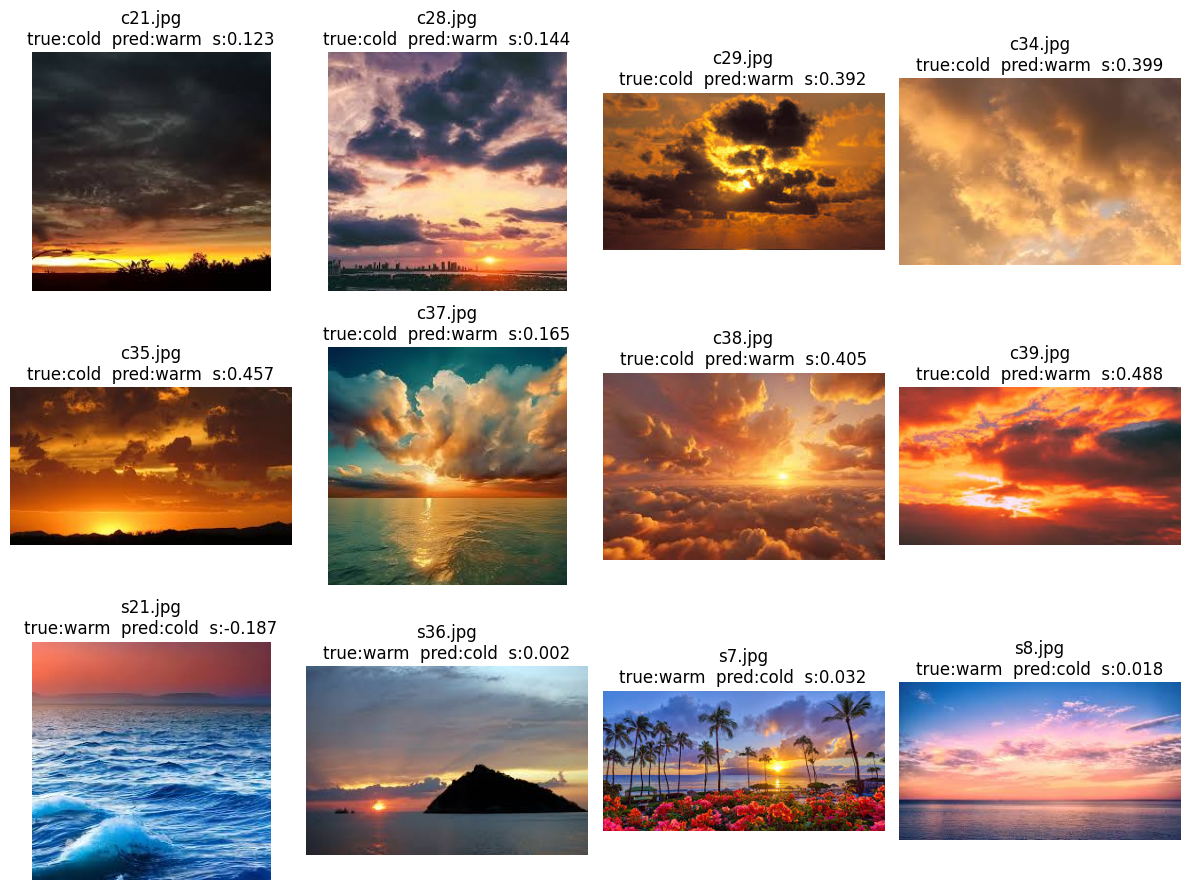

In [72]:
idx_wrong = np.where(y_true!=pred_opt)[0]
print("name\tscore\ttrue\tpred")
for k in idx_wrong:
    print(f"{names[k]}\t{scores[k]:.4f}\t{y_true[k]}\t{pred_opt[k]}")

if len(idx_wrong)>0:
    cols = 4
    rows = math.ceil(len(idx_wrong)/cols)
    plt.figure(figsize=(12,3*rows))
    for i,k in enumerate(idx_wrong[:rows*cols]):
        im = Image.open(files[k])
        plt.subplot(rows,cols,i+1)
        plt.imshow(im)
        plt.axis("off")
        plt.title(f"{names[k]}\ntrue:{y_true[k]}  pred:{pred_opt[k]}  s:{scores[k]:.3f}")
    plt.tight_layout()
    plt.show()
else:
    print("no misclassified images")

